--- N = 3 bits ---
Número de níveis (L): 8
Resolução (Delta V): 0.125000 V
Erro Máximo Medido: 0.062333 V (Teórico: 0.062500 V)
Erro RMS: 0.033892 V

--- N = 4 bits ---
Número de níveis (L): 16
Resolução (Delta V): 0.062500 V
Erro Máximo Medido: 0.031191 V (Teórico: 0.031250 V)
Erro RMS: 0.017290 V

--- N = 8 bits ---
Número de níveis (L): 256
Resolução (Delta V): 0.003906 V
Erro Máximo Medido: 0.001952 V (Teórico: 0.001953 V)
Erro RMS: 0.001161 V



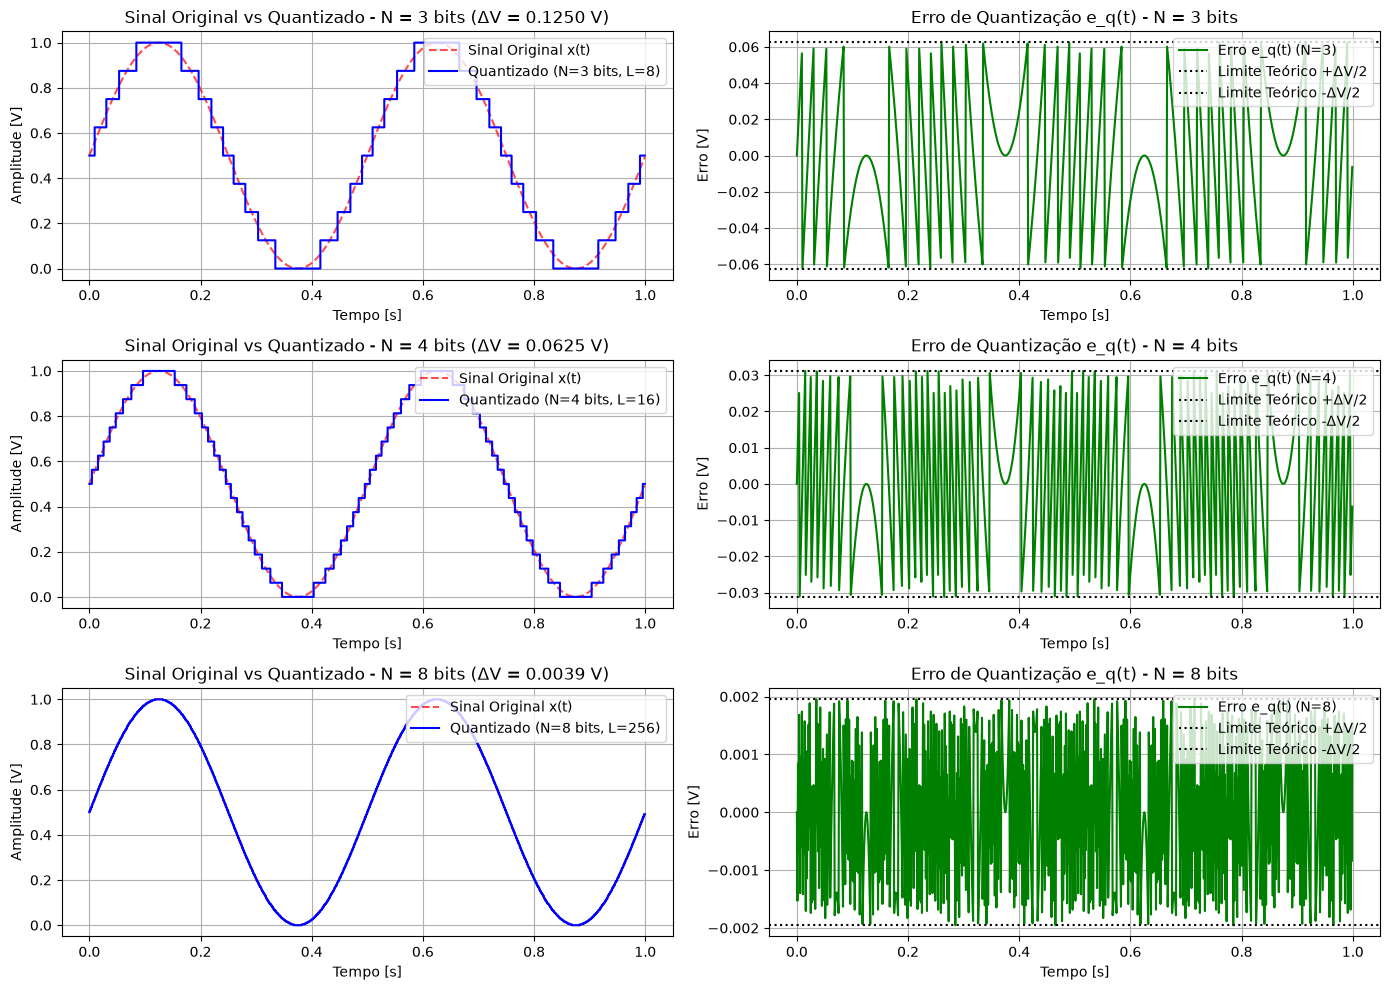

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros de Simulação
fs = 1000            # Frequência de amostragem (Hz)
t = np.linspace(0, 1, fs, endpoint=False) # Vetor de tempo (1 segundo)
f0 = 2               # Frequência da senóide (2 Hz)
Vref = 1.0           # Tensão de referência (0 V a 1.0 V)

# Sinal Original (senóide ajustada para a faixa [0, Vref])
x = 0.5 * (1 + np.sin(2 * np.pi * f0 * t))

# Bits a comparar
bits = [3, 4, 8]

# Preparação da Figura
plt.figure(figsize=(14, 10))

for i, N in enumerate(bits):
    # Cálculo do número de níveis e resolução
    L = 2**N
    delta_v = Vref / L
    
    # Quantização por Arredondamento
    x_quant = np.round(x / delta_v) * delta_v
    x_quant = np.clip(x_quant, 0, Vref) # Limitação à faixa [0, Vref]
    
    # Erro de Quantização
    e_q = x - x_quant
    rmse = np.sqrt(np.mean(e_q**2))
    max_err = np.max(np.abs(e_q))
    
    # Exibição dos dados no console
    print(f"--- N = {N} bits ---")
    print(f"Número de níveis (L): {L}")
    print(f"Resolução (Delta V): {delta_v:.6f} V")
    print(f"Erro Máximo Medido: {max_err:.6f} V (Teórico: {delta_v/2:.6f} V)")
    print(f"Erro RMS: {rmse:.6f} V\n")
    
    # Plot do Sinal Quantizado
    plt.subplot(3, 2, 2*i + 1)
    plt.plot(t, x, 'r--', label='Sinal Original x(t)', alpha=0.7)
    plt.step(t, x_quant, 'b', where='mid', label=f'Quantizado (N={N} bits, L={L})')
    plt.title(f'Sinal Original vs Quantizado - N = {N} bits (ΔV = {delta_v:.4f} V)')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Amplitude [V]')
    plt.grid(True)
    plt.legend(loc='upper right')
    
    # Plot do Erro de Quantização
    plt.subplot(3, 2, 2*i + 2)
    plt.plot(t, e_q, 'g', label=f'Erro e_q(t) (N={N})')
    plt.axhline(delta_v/2, color='k', linestyle=':', label='Limite Teórico +ΔV/2')
    plt.axhline(-delta_v/2, color='k', linestyle=':', label='Limite Teórico -ΔV/2')
    plt.title(f'Erro de Quantização e_q(t) - N = {N} bits')
    plt.xlabel('Tempo [s]')
    plt.ylabel('Erro [V]')
    plt.grid(True)
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()